In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator
import warnings
warnings.filterwarnings("ignore")



from fieldparser import create_interpolators

Evaluating interpolator at 300000 points...


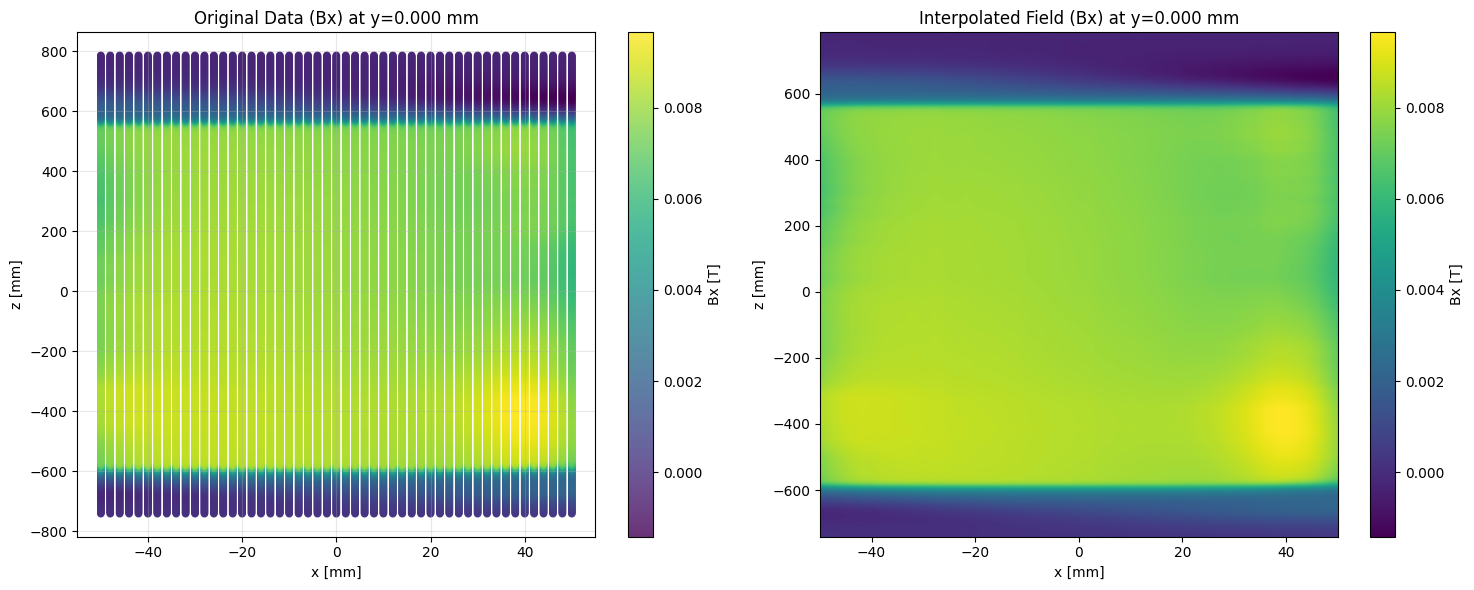


Statistics for Bx:
  Original data range: [-1.415977e-03, 9.650375e-03] T
  Interpolated range: [-1.415007e-03, 9.650214e-03] T
  Number of original points: 39015
  Interpolation grid: 500 . 600 = 300000 points
Evaluating interpolator at 300000 points...


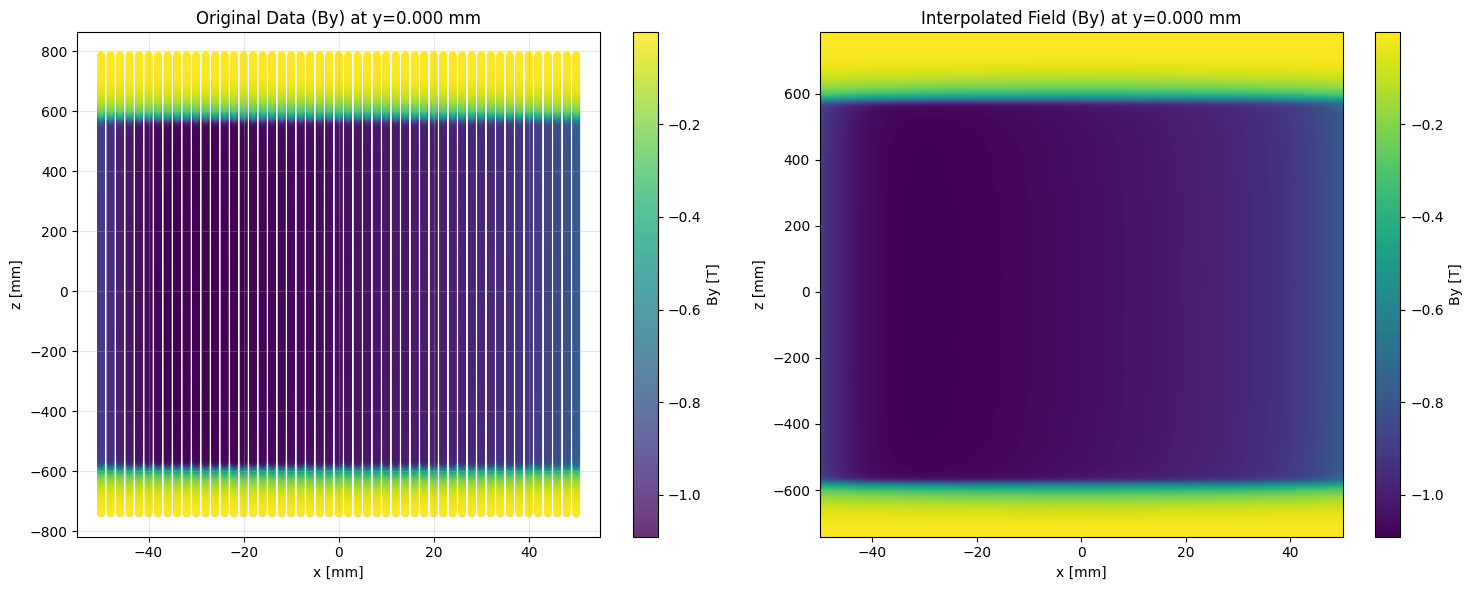


Statistics for By:
  Original data range: [-1.090445e+00, -1.295179e-03] T
  Interpolated range: [-1.090433e+00, -1.295179e-03] T
  Number of original points: 39015
  Interpolation grid: 500 . 600 = 300000 points
Evaluating interpolator at 300000 points...


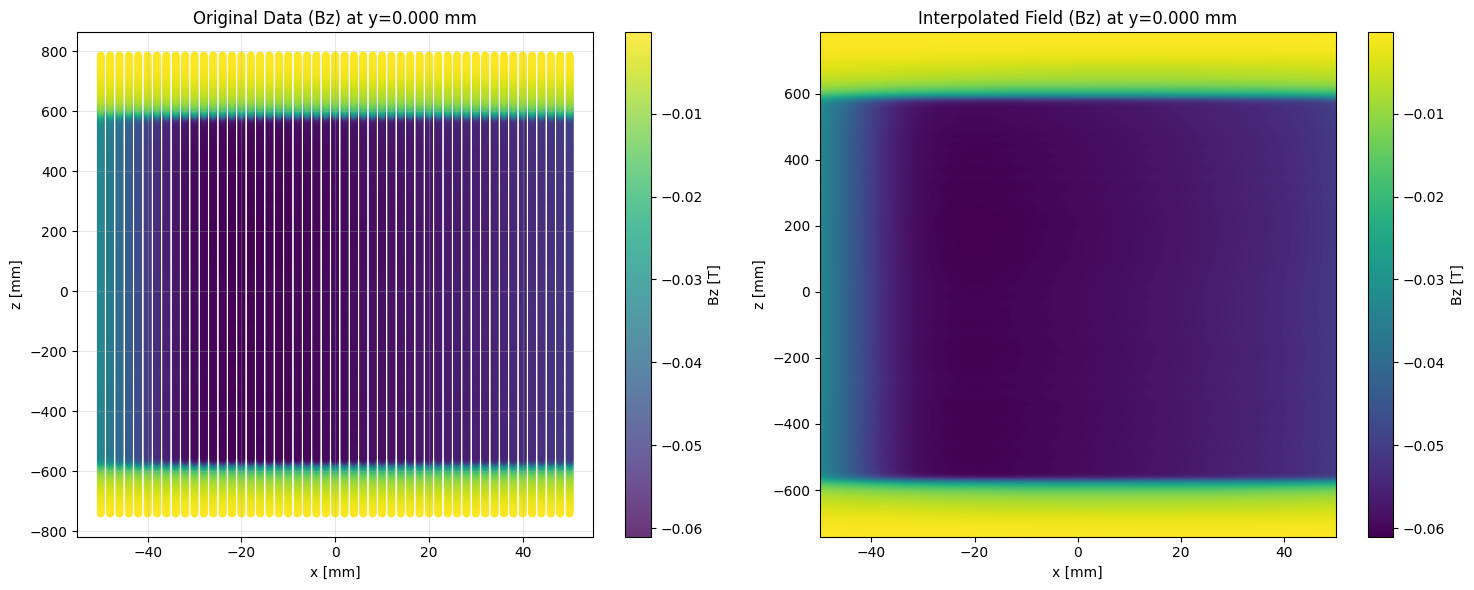


Statistics for Bz:
  Original data range: [-6.101152e-02, -2.074260e-04] T
  Interpolated range: [-6.100958e-02, -2.074523e-04] T
  Number of original points: 39015
  Interpolation grid: 500 . 600 = 300000 points
Evaluating interpolator at 300000 points...


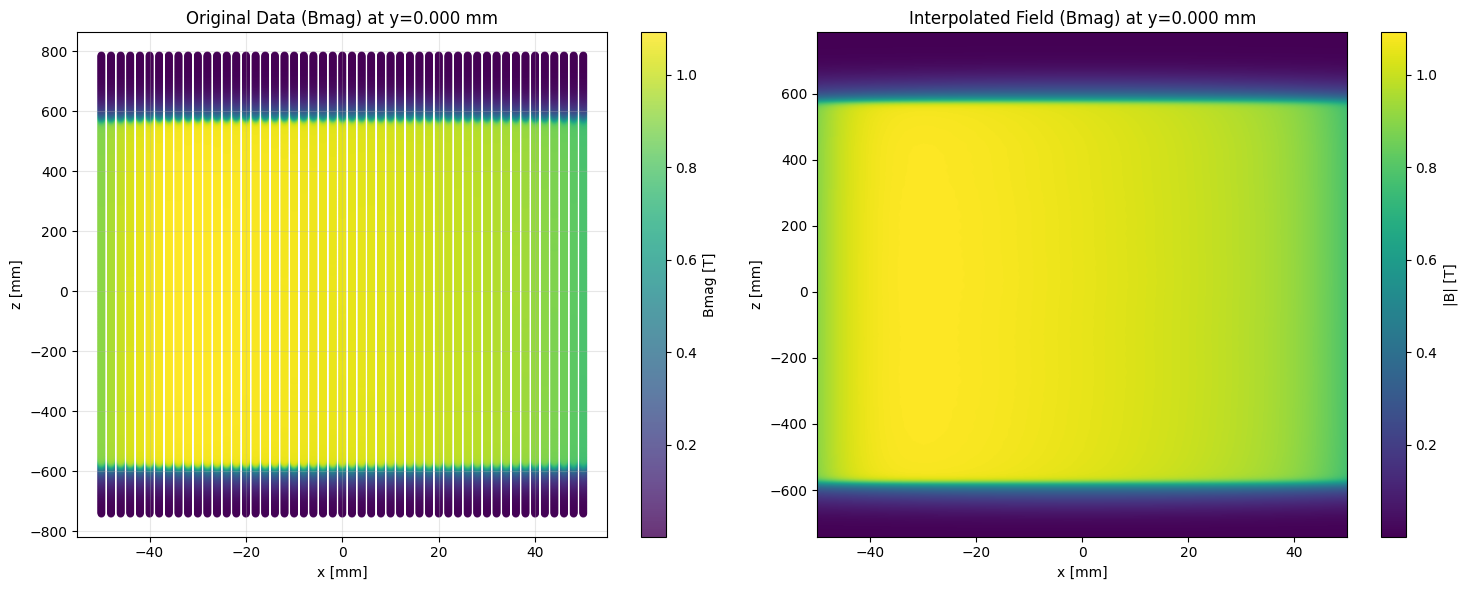


Statistics for Bmag:
  Original data range: [1.340976e-03, 1.092087e+00] T
  Interpolated range: [1.340976e-03, 1.092077e+00] T
  Number of original points: 39015
  Interpolation grid: 500 . 600 = 300000 points


In [2]:
file_name = "2017-03-06_BD-004_Model09_Hall_I=991.63A.dat"   

df = pd.read_csv(file_name, sep="\t", skiprows=15)   # skiprows=15 only in this case!
# some adjusts (also only in this case!)
df.drop(index=[0], inplace=True)
df = df.dropna(axis=1)
df = df.set_axis(["x_mm", "y_mm", "z_mm", "Bx_T", "By_T", "Bz_T"], axis=1)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()



# creates the interpolator
def create_interpolators(df):
    
    grade = list(zip(df['x_mm'], df['z_mm']))


    # creates functions to define each field component
    fbx_plano = LinearNDInterpolator(grade, df['Bx_T'], fill_value=0)
    fby_plano = LinearNDInterpolator(grade, df['By_T'], fill_value=0)
    fbz_plano = LinearNDInterpolator(grade, df['Bz_T'], fill_value=0)   


    def interp_func(point):
        # Note: your original code uses only x and z coordinates (2D interpolation)
        point_ = np.array([point[0], point[2]])


        fbx = fbx_plano(point_)
        fby = fby_plano(point_)
        fbz = fbz_plano(point_)

        
        return [
            fbx,
            fby,
            fbz
        ]
    

    return interp_func



interp_data = create_interpolators(df)


def plot_comparison_2d(interp_func, df, component='By', res=(500, 600), y_fixed=None):
    
    # Convert to numeric and ensure consistent units
    df = df.copy()
    for col in ['x_mm', 'y_mm', 'z_mm', 'Bx_T', 'By_T', 'Bz_T']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    
    # Get unique coordinate values
    x_vals = np.sort(df["x_mm"].unique())
    y_vals = np.sort(df["y_mm"].unique())
    z_vals = np.sort(df["z_mm"].unique())
    
    # Set y coordinate if not provided
    if y_fixed is None:
        y_fixed = y_vals[0]
    
    # Filter original data for this y-plane
    df_plane = df[np.isclose(df['y_mm'], y_fixed, atol=1e-6)]
    
    if len(df_plane) == 0:
        raise ValueError(f"No data found at y={y_fixed} mm")
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Original data (scatter plot)
    if component == 'Bx':
        field_vals = df_plane['Bx_T'].values
    elif component == 'By':
        field_vals = df_plane['By_T'].values
    elif component == 'Bz':
        field_vals = df_plane['Bz_T'].values
    elif component == 'Bmag':
        field_vals = np.sqrt(df_plane['Bx_T']**2 + df_plane['By_T']**2 + df_plane['Bz_T']**2).values
    else:
        raise ValueError("component must be 'Bx', 'By', 'Bz', or 'Bmag'")
    
    sc1 = ax1.scatter(df_plane['x_mm'], df_plane['z_mm'], c=field_vals, 
                     s=20, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('z [mm]')
    ax1.set_title(f'Original Data ({component}) at y={y_fixed:.3f} mm')
    plt.colorbar(sc1, ax=ax1, label=f'{component} [T]')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Interpolated data (heatmap)
    # Create dense grid for interpolation
    nx, nz = res
    Xg = np.linspace(x_vals.min(), x_vals.max(), nx)
    Zg = np.linspace(z_vals.min(), z_vals.max(), nz)
    X, Z = np.meshgrid(Xg, Zg, indexing='ij')
    
    # Initialize arrays for field components
    Bx_grid = np.zeros_like(X)
    By_grid = np.zeros_like(X)
    Bz_grid = np.zeros_like(X)
    
    # Evaluate interpolator at each grid point
    print(f"Evaluating interpolator at {X.size} points...")
    for i in range(nx):
        for j in range(nz):
            # Create point (x, y_fixed, z)
            point = np.array([Xg[i], y_fixed, Zg[j]])
            # Get interpolated values
            Bx_val, By_val, Bz_val = interp_func(point)
            Bx_grid[i, j] = Bx_val
            By_grid[i, j] = By_val
            Bz_grid[i, j] = Bz_val
    
    # Select the appropriate component for display
    if component == 'Bx':
        Img = Bx_grid
        cbar_label = 'Bx [T]'
    elif component == 'By':
        Img = By_grid
        cbar_label = 'By [T]'
    elif component == 'Bz':
        Img = Bz_grid
        cbar_label = 'Bz [T]'
    elif component == 'Bmag':
        Img = np.sqrt(Bx_grid**2 + By_grid**2 + Bz_grid**2)
        cbar_label = '|B| [T]'
    
    # Plot the interpolated field
    extent = [Xg.min(), Xg.max(), Zg.min(), Zg.max()]
    im = ax2.imshow(Img.T, origin='lower', aspect='auto', 
                   extent=extent, cmap='viridis')
    ax2.set_xlabel('x [mm]')
    ax2.set_ylabel('z [mm]')
    ax2.set_title(f'Interpolated Field ({component}) at y={y_fixed:.3f} mm')
    plt.colorbar(im, ax=ax2, label=cbar_label)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nStatistics for {component}:")
    print(f"  Original data range: [{field_vals.min():.6e}, {field_vals.max():.6e}] T")
    print(f"  Interpolated range: [{Img.min():.6e}, {Img.max():.6e}] T")
    print(f"  Number of original points: {len(df_plane)}")
    print(f"  Interpolation grid: {nx} × {nz} = {nx*nz} points")
    
    return fig, (ax1, ax2)

# Optimized version using vectorization (faster but requires more memory)
def plot_comparison_2d_vectorized(interp_func, df, component='Bx', res=(500, 600), y_fixed=None):
    """
    Vectorized version for better performance
    """
    
    # Convert to numeric and ensure consistent units
    df = df.copy()
    for col in ['x_mm', 'y_mm', 'z_mm', 'Bx_T', 'By_T', 'Bz_T']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    
    # Get unique coordinate values
    x_vals = np.sort(df["x_mm"].unique())
    y_vals = np.sort(df["y_mm"].unique())
    z_vals = np.sort(df["z_mm"].unique())
    
    # Set y coordinate if not provided
    if y_fixed is None:
        y_fixed = y_vals[0]
    
    # Filter original data for this y-plane
    df_plane = df[np.isclose(df['y_mm'], y_fixed, atol=1e-6)]
    
    if len(df_plane) == 0:
        raise ValueError(f"No data found at y={y_fixed} mm")
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Original data (scatter plot)
    if component == 'Bx':
        field_vals = df_plane['Bx_T'].values
    elif component == 'By':
        field_vals = df_plane['By_T'].values
    elif component == 'Bz':
        field_vals = df_plane['Bz_T'].values
    elif component == 'Bmag':
        field_vals = np.sqrt(df_plane['Bx_T']**2 + df_plane['By_T']**2 + df_plane['Bz_T']**2).values
    else:
        raise ValueError("component must be 'Bx', 'By', 'Bz', or 'Bmag'")
    
    sc1 = ax1.scatter(df_plane['x_mm'], df_plane['z_mm'], c=field_vals, 
                     s=20, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('z [mm]')
    ax1.set_title(f'Original Data ({component}) at y={y_fixed:.3f} mm')
    plt.colorbar(sc1, ax=ax1, label=f'{component} [T]')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Interpolated data (heatmap) - VECTORIZED APPROACH
    nx, nz = res
    Xg = np.linspace(x_vals.min(), x_vals.max(), nx)
    Zg = np.linspace(z_vals.min(), z_vals.max(), nz)
    X, Z = np.meshgrid(Xg, Zg, indexing='ij')
    
    # Create all points at once
    points = np.column_stack([
        X.ravel(),
        np.full(X.size, y_fixed),
        Z.ravel()
    ])
    
    print(f"Evaluating interpolator at {len(points)} points...")
    
    # Evaluate interpolator at all points
    results = np.array([interp_func(p) for p in points])
    Bx_grid = results[:, 0].reshape(X.shape)
    By_grid = results[:, 1].reshape(X.shape)
    Bz_grid = results[:, 2].reshape(X.shape)
    
    # Select the appropriate component for display
    if component == 'Bx':
        Img = Bx_grid
        cbar_label = 'Bx [T]'
    elif component == 'By':
        Img = By_grid
        cbar_label = 'By [T]'
    elif component == 'Bz':
        Img = Bz_grid
        cbar_label = 'Bz [T]'
    elif component == 'Bmag':
        Img = np.sqrt(Bx_grid**2 + By_grid**2 + Bz_grid**2)
        cbar_label = '|B| [T]'
    
    # Plot the interpolated field
    extent = [Xg.min(), Xg.max(), Zg.min(), Zg.max()]
    im = ax2.imshow(Img.T, origin='lower', aspect='auto', 
                   extent=extent, cmap='viridis')
    ax2.set_xlabel('x [mm]')
    ax2.set_ylabel('z [mm]')
    ax2.set_title(f'Interpolated Field ({component}) at y={y_fixed:.3f} mm')
    plt.colorbar(im, ax=ax2, label=cbar_label)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nStatistics for {component}:")
    print(f"  Original data range: [{field_vals.min():.6e}, {field_vals.max():.6e}] T")
    print(f"  Interpolated range: [{Img.min():.6e}, {Img.max():.6e}] T")
    print(f"  Number of original points: {len(df_plane)}")
    print(f"  Interpolation grid: {nx} . {nz} = {nx*nz} points")
    
    return fig, (ax1, ax2)

# Example usage:
if __name__ == "__main__":
    
    # Create interpolator
    interp_func = create_interpolators(df)
    
    # Plot comparisons - use the vectorized version for better performance
    plot_comparison_2d_vectorized(interp_func, df, component='Bx', res=(500, 600))
    plot_comparison_2d_vectorized(interp_func, df, component='By', res=(500, 600))
    plot_comparison_2d_vectorized(interp_func, df, component='Bz', res=(500, 600))
    plot_comparison_2d_vectorized(interp_func, df, component='Bmag', res=(500, 600))